In [1]:
import awkward as ak
import numpy as np
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import sys
from coffea.nanoevents import NanoEventsFactory #, TreeMakerSchema
import treemaker
from treemaker import TreeMakerSchema
import coffea
print(coffea.__version__)
print(ak.__version__)

from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
np.set_printoptions(linewidth=500)

0.7.21
1.10.3


In [2]:
# samples = [
#     #{"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-1000_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root"},
#     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/8kevents/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root"},

#     #   {"rinv": 1, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.1$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p1_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root"},
# #     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root"},
# #     {"rinv": 5, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.5$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p5_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root"},
# #     {"rinv": 7, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.7$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p7_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root"},
    
# #     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-1500_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root
# #     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-100_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root
# #     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-1_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root

# #     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-50_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root
# #     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-3000_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root
# #     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-4000_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root
# #     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-600_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root
# #     {"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-800_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000-out_RA2AnalysisTree.root


#     #{"rinv": 3, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname": "root://cmseos.fnal.gov//store/user/lpcdarkqcd/tchannel_UL/2018/Full/PrivateSamples/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000/0_RA2AnalysisTree.root"},
#     #{"rinv": 5, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.5$", "fname": "root://cmseos.fnal.gov//store/user/lpcdarkqcd/tchannel_UL/2018/Full/PrivateSamples/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p5_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000/0_RA2AnalysisTree.root"},
#     #{"rinv": 7, "legname": r"$m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.7$", "fname": "root://cmseos.fnal.gov//store/user/lpcdarkqcd/tchannel_UL/2018/Full/PrivateSamples/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p7_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000/0_RA2AnalysisTree.root"}
# # ]

samples = [{"rinv": 3, "legname": r"$m_{med} = 2000$ GeV, $m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.3$", "fname":"/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000_RA2AnalysisTree.root"},
#            {"rinv": 1, "legname": r"$m_{med} = 2000$ GeV, $m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.1$", "fname":"/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p1_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000_RA2AnalysisTree.root"},
#            {"rinv": 7, "legname": r"$m_{med} = 2000$ GeV, $m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.7$", "fname":"/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-20_rinv-0p7_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000_RA2AnalysisTree.root"},
#            {"rinv": 7, "legname": r"$m_{med} = 600$ GeV, $m_{\mathrm{dark}} = 20$ GeV, $r_{\mathrm{inv}} = 0.7$", "fname":"/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-600_mDark-20_rinv-0p7_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000_RA2AnalysisTree.root"},
#            {"rinv": 3, "legname": r"$m_{med} = 2000$ GeV, $m_{\mathrm{dark}} = 100$ GeV, $r_{\mathrm{inv}} = 0.7$", "fname":"/uscms/home/easmith/svj/CMSSW_10_6_29_patch1/src/TreeMaker/run/SVJ_UL2018_t-channel_mMed-2000_mDark-100_rinv-0p3_alpha-peak_yukawa-1_13TeV-madgraphMLM-pythia8_n-1000_RA2AnalysisTree.root"},
           ]


In [3]:
for sample in samples:
   sample["events"] = NanoEventsFactory.from_root(
       file=sample["fname"],
       treepath="TreeMaker2/PreSelection",
       schemaclass=TreeMakerSchema,
       metadata={"dataset": sample["legname"]},
   ).events()
   #print(sample["events"]["JetsAK8"])
   #print(ak.size(sample["events"]["EvtNum"]))

   events = sample["events"]
   print(events)


[{RunNum: 1, LumiBlockNum: 1, EvtNum: 1018, ... o: 9}]}]


/opt/conda/lib/python3.8/site-packages/awkward/_connect/_numpy.py:195: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(


GenJet
Unmatched 63675
Total 312037
[[0], [0.375, 0], [0.167, 0.107], [], [], ... [], [0, 0, 0], [0.118, 0], [0]]
[0, 9, 0, 6, 3, 0, 0, 18, 4, 5, 0, 0, 0, ... 0, 3, 0, 5, 1, 0, 12, 0, 0, 0, 9, 0, 0]

RecoJet
Unmatched 24445
Total 272903
Counter({211: 8877, -211: 8319, 130: 4130, 22: 2820, -11: 83, 11: 80, -13: 64, 13: 53, 1: 18, 2: 1})
24445
len constituents Assigned First [[[], [7], [10]], [[], [], [15], ... 3, 6, 0], [1, 5, 9, 7, 2, 6], [3, 5, 6, 1]]]
len constituents Assigned second [[[], [7], [10]], [[], [], [15], ... 3, 6, 0], [1, 5, 9, 7, 2, 6], [3, 5, 6, 1]]]
len constituents matchStage [[[], [7], [10]], [[], [], [15], ... 3, 6, 0], [1, 5, 9, 7, 2, 6], [3, 5, 6, 1]]]
len constituents reco pdgid [[[], [7], [10]], [[], [], [15], ... 3, 6, 0], [1, 5, 9, 7, 2, 6], [3, 5, 6, 1]]]
Number of Constituents assigned to dark hadrons: 24445
Number of Constituents unmatched (match stage = -1): 21
Number of Constituents unmatched (match stage = 0): 70134
Number of Constituents unmatched (matc

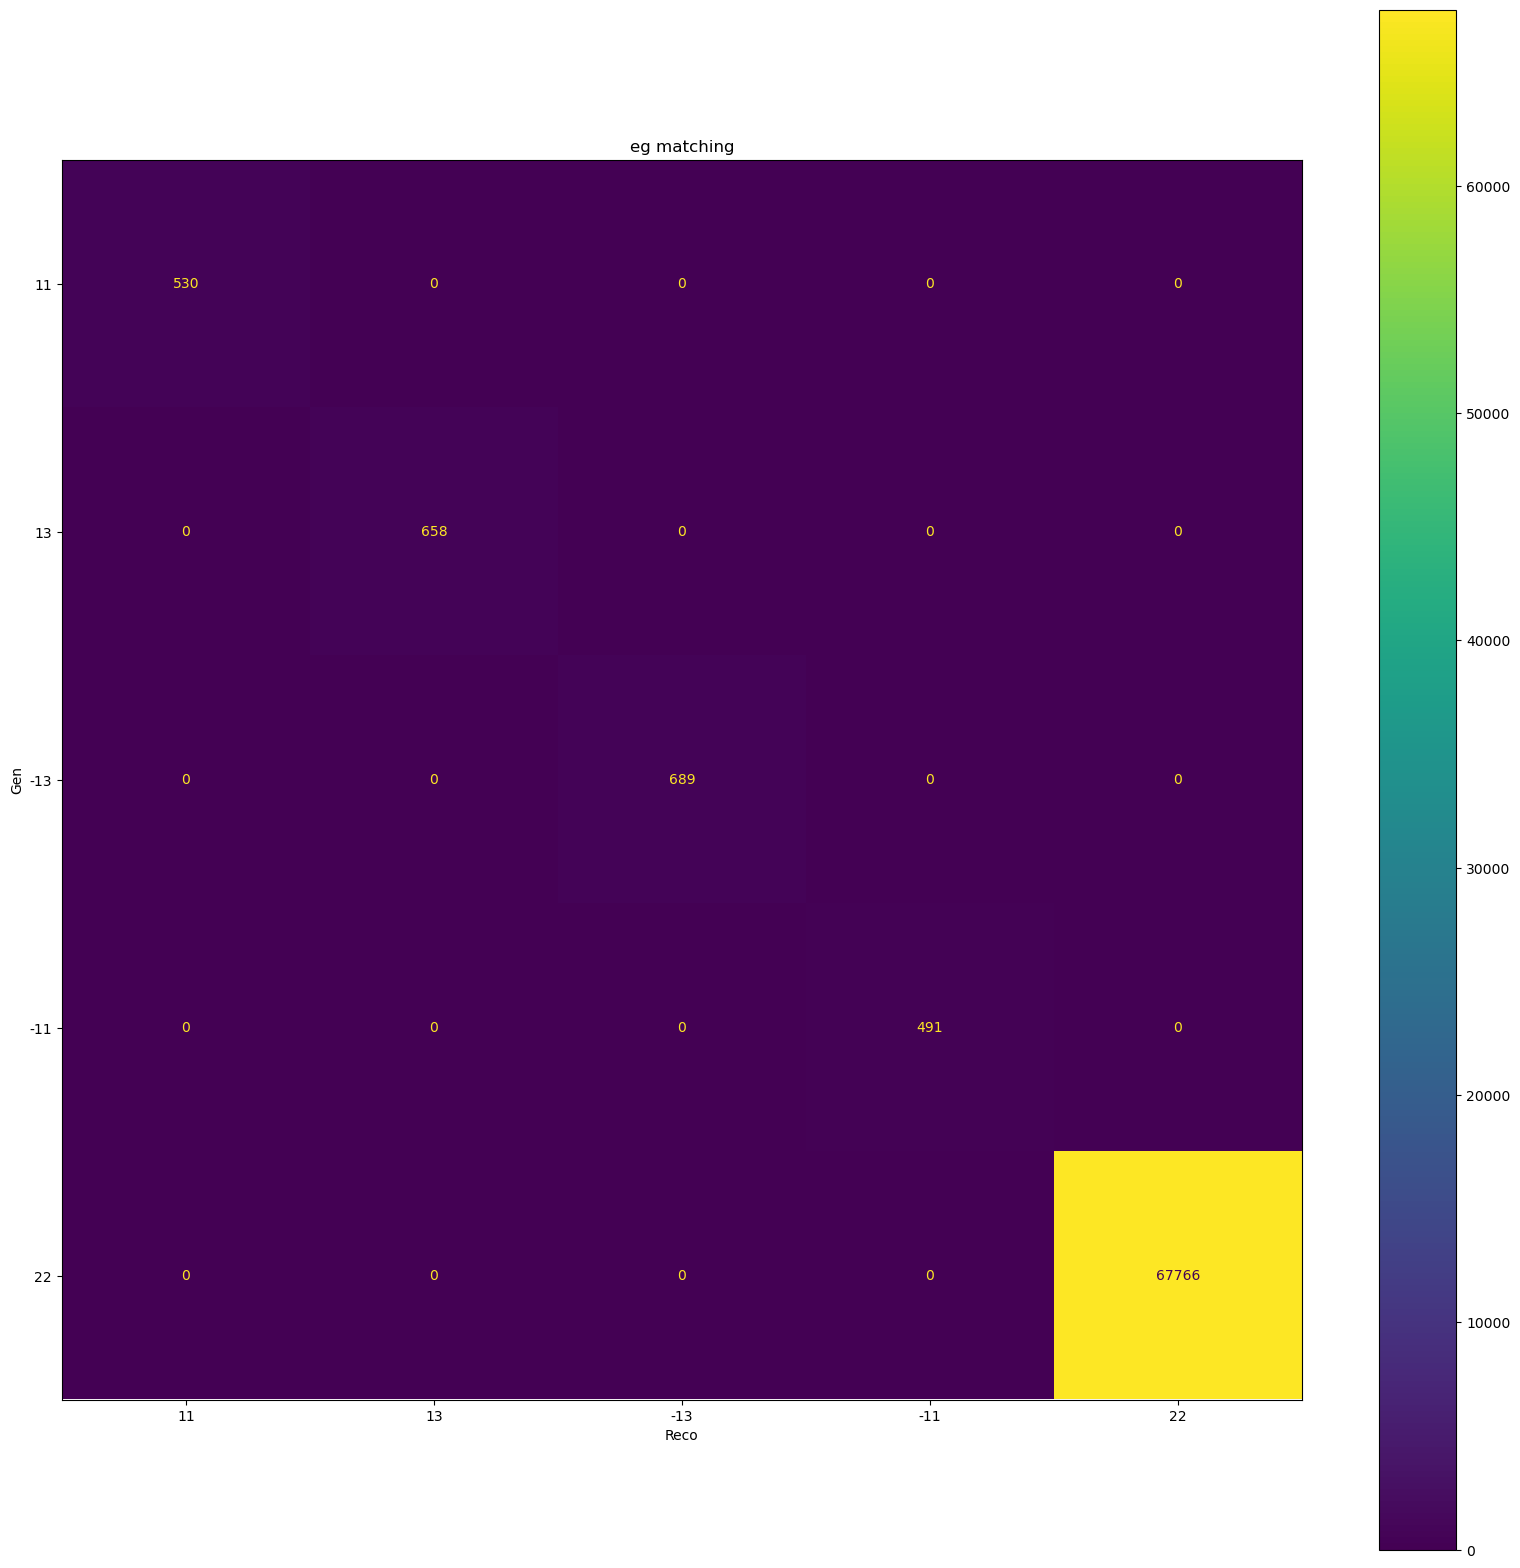

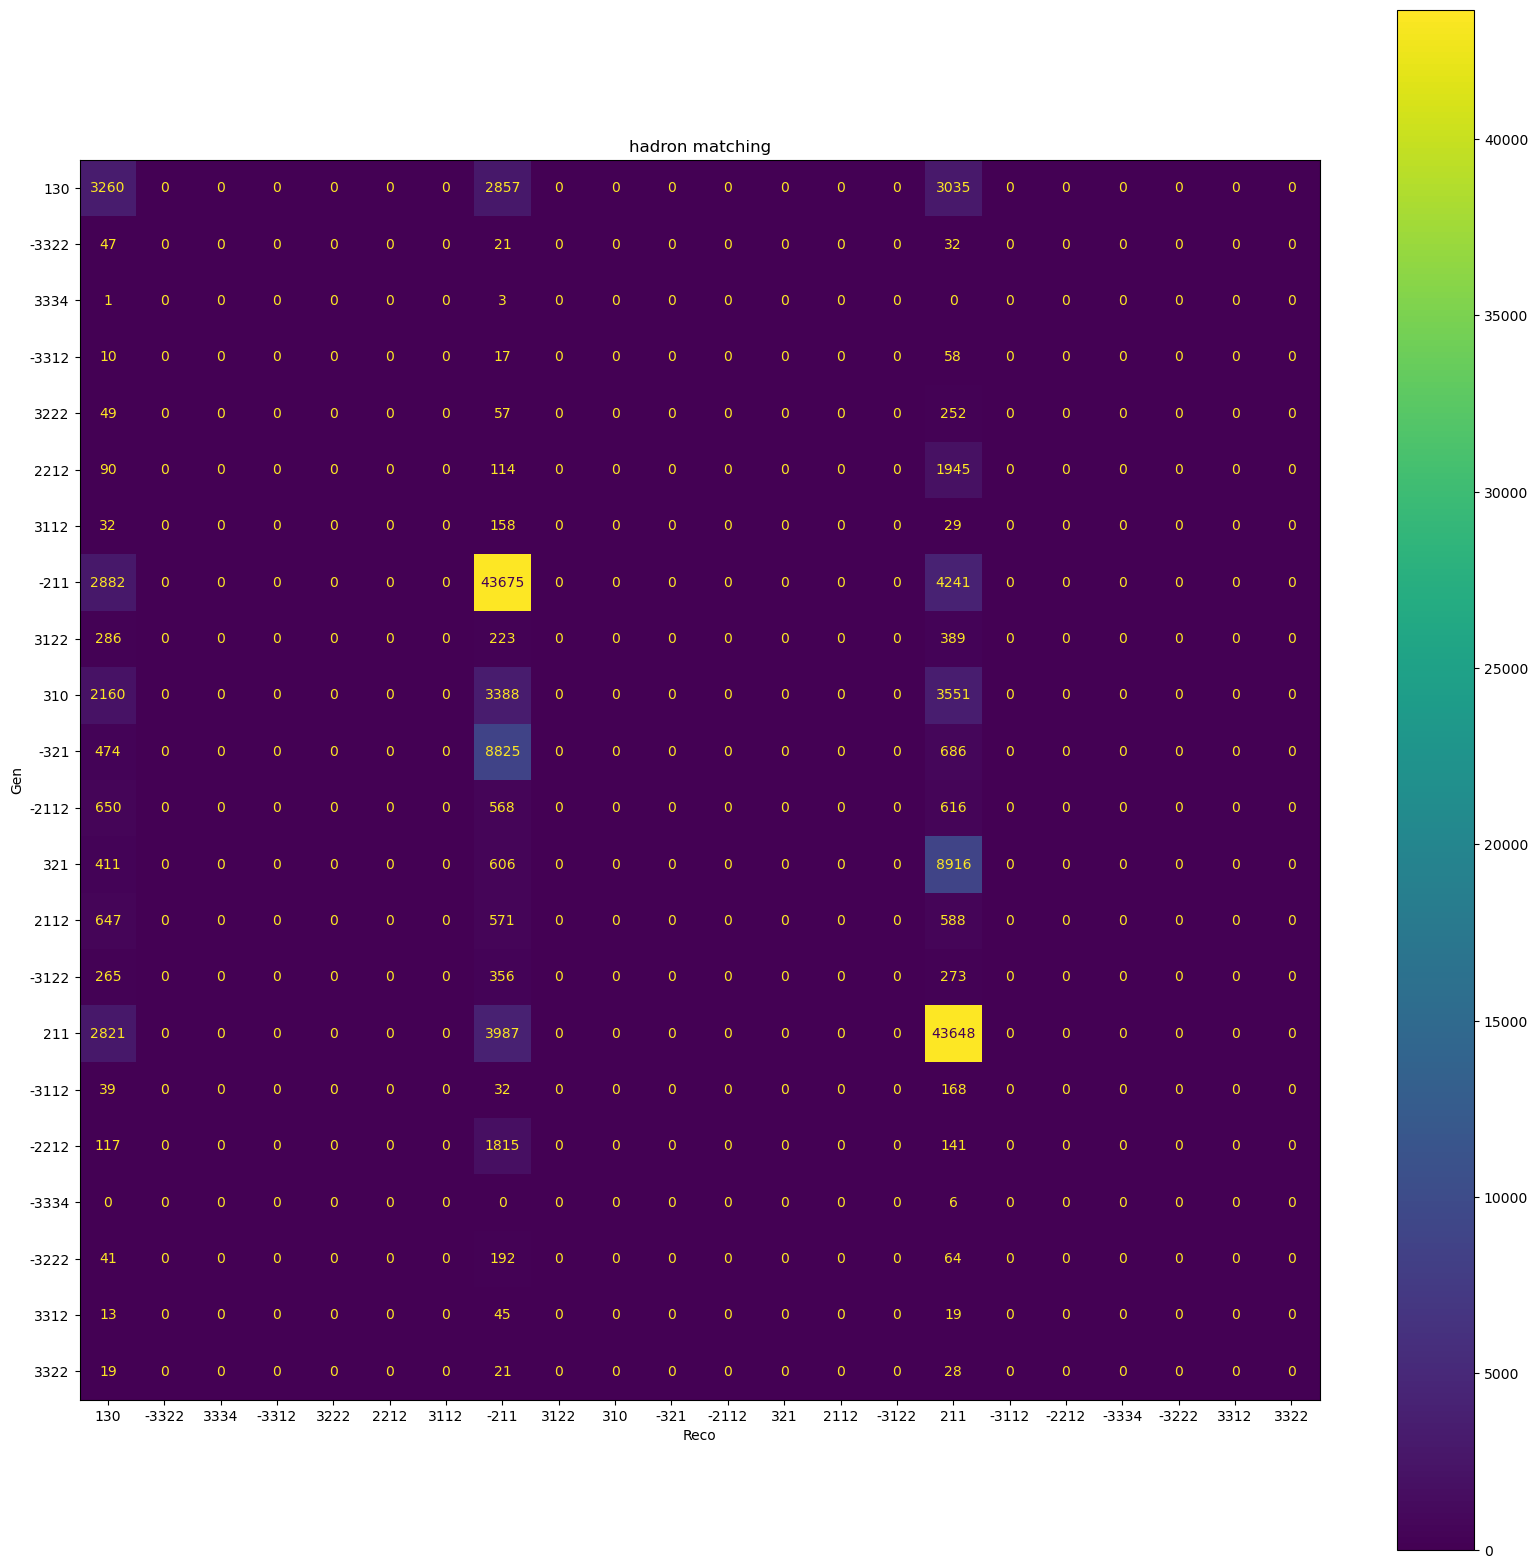

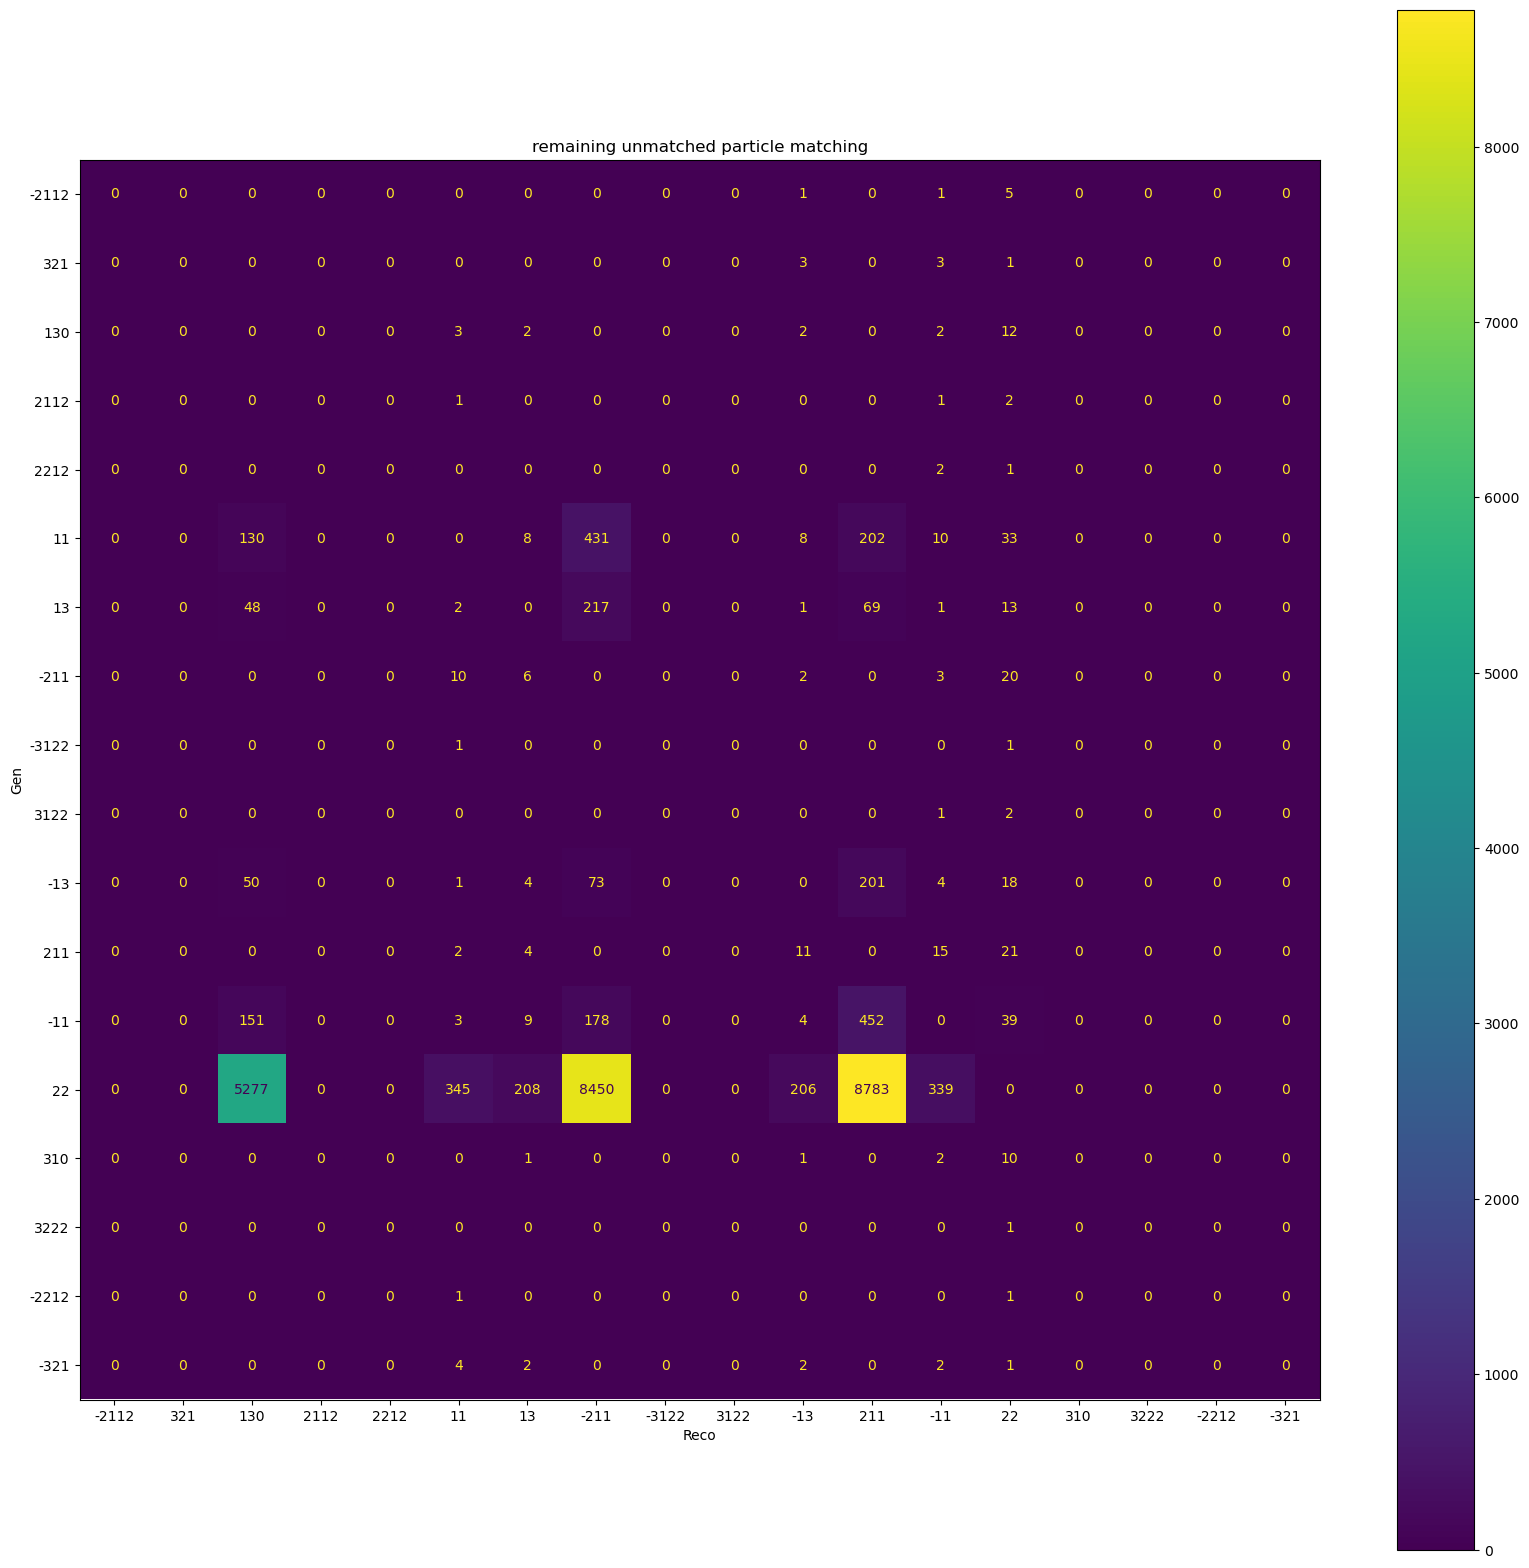

In [4]:
from collections import Counter
for sample in samples:
    events = sample["events"]
    events["darkHadronJetMassAll"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJets.mass,nan=0)
    events["nDarkHadrons"] = ak.count(events["darkHadronJetMassAll"], axis=2)
    events["DarkHadronJetNConstituents"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJetsMultiplicity,nan=0)
    #events["darkHadronJetMassAllMax"] = ak.max(events["darkHadronJetMassAll"], axis=2)
    #events["darkHadronJetMassAllAvg"] = ak.mean(events["darkHadronJetMassAll"], axis=2)
    #some_mask = events["GenJetsAK8"][:,0:2].darkHadronJetsMultiplicity>int(0.6*sample["mdark"])
    mask1 = events["GenJetsAK8"].darkHadronJetsMultiplicity>1;
    mask2 = events["GenJetsAK8"].darkHadronJetsMultiplicity>2;
    mask3 = events["GenJetsAK8"].darkHadronJetsMultiplicity>3;
    matchedMask = events["JetsAK8"].genIndex > -1;
    #some_mask = events["GenJetsAK8"][:,0:2].darkHadronJetsTau1==0;
    #events["darkHadronJetMassSome"] = ak.nan_to_num(events["GenJetsAK8"][:,0:2].darkHadronJets.mass[some_mask],nan=0)
    #events["darkHadronJetMassSomeMax"] = ak.max(events["darkHadronJetMassSome"], axis=2)
    #events["darkHadronJetMassSomeAvg"] = ak.mean(events["darkHadronJetMassSome"], axis=2)
#     events["darkHadronJetsTau1"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJetsTau1[mask1],nan=0)
#     events["darkHadronJetsTau2"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJetsTau2[mask2],nan=0)
#     events["darkHadronJetsTau3"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJetsTau3[mask3],nan=0)
# #     events["darkHadronJetsTau1"] = ak.nan_to_num(events["GenJetsAK8"][:,0:2].darkHadronJetsTau1,nan=0)
# #     events["darkHadronJetsTau2"] = ak.nan_to_num(events["GenJetsAK8"][:,0:2].darkHadronJetsTau2,nan=0)
# #     events["darkHadronJetsTau3"] = ak.nan_to_num(events["GenJetsAK8"][:,0:2].darkHadronJetsTau3,nan=0)
#     events["tau3tau2Ratio"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJetsTau3[mask3],nan=0) / ak.nan_to_num(events["GenJetsAK8"].darkHadronJetsTau2[mask3],nan=0)
#     events["tau2tau1Ratio"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJetsTau2[mask2],nan=0) / ak.nan_to_num(events["GenJetsAK8"].darkHadronJetsTau1[mask2],nan=0)
    
    #events["darkHadronJetMassAll"] = ak.nan_to_num(events["GenJetsAK8"][:,0:2].darkHadronJets.mass,nan=0)
#     print(ak.sum(events["darkHadronJetsTau1"]==0))
#     print(ak.sum(events["darkHadronJetsTau2"]==0))
#     print(ak.sum(events["darkHadronJetsTau3"]==0))
#     print(ak.sum(events["darkHadronJetsTau1"]<0.05))
#     print(ak.sum(events["darkHadronJetsTau2"]<0.05))
#     print(ak.sum(events["darkHadronJetsTau3"]<0.05))

    #events["lundSystSubjets"] = ak.nan_to_num(events["GenJetsAK8"][:,0:2].recolundSystSubjets, nan=0)
    #print(len(events[2]["lundSystSubjets"][-1]))
    #print(events["GenJetsAK8"][:,0:2].nConstituents)
    #print(events["GenJetsAK8"][:,0:2].nConstituentsUnmatched)
    #print(events["GenJetsAK8"][:,0:2].nLundSubjets)
    #events["nLundSubjets"] = ak.nan_to_num(events["GenJetsAK8"][:,0:2].nLundSubjets,nan=0)
    #print(ak.count(events["darkHadronJetMassAll"], axis=2))
    #print(ak.count(events["JetsAK8"][:,0:2].pt))
   
    #maskGenIndex = events["JetsAK8"].genIndex ;
    #print(events["JetsAK8"][:,0:2].fields)
    maskGenIndex = ak.mask(events["JetsAK8"].genIndex, events["JetsAK8"].genIndex >= 0)
    
    events["GenJetsNConstituents"] = ak.nan_to_num(events["GenJetsAK8"].nConstituents, nan=0)[maskGenIndex]
    events["GenJetsNConstituentsDH"] = ak.nan_to_num(events["GenJetsAK8"].nConstituentsDarkHadrons, nan=0)[maskGenIndex]
    events["GenJetsNConstituentsUnmatched"] = ak.nan_to_num(events["GenJetsAK8"].nConstituentsUnmatched, nan=0)[maskGenIndex]
    events["JetsNConstituents"] = ak.nan_to_num(events["JetsAK8"].nConstituentsHiddenSector, nan=0)
    events["JetsGenJetIndex"] = ak.nan_to_num(events["JetsAK8"].genIndex, nan=0)
    events["GenJetsNConstituentsUnmatched"] = ak.nan_to_num(events["GenJetsAK8"].nConstituentsUnmatched, nan=0)[maskGenIndex]
    events["JetsNConstituentsUnmatched"] = ak.nan_to_num(events["JetsAK8"].nConstituentsHiddenSectorUnmatched, nan=0)
    #events["NConstituentsMatched"] = events["GenJetsNConstituents"] - events["GenJetsNConstituentsUnmatched"]     
    events["GenJetsDarkHadronConstituents"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJets.constituents.pt, nan=0)

    
    maskhv = events["GenJetsAK8"].hvCategory[maskGenIndex] == 3
    #print(events["GenJetsAK8"].hvCategory[maskGenIndex])
    for i in [3, 9, 11, 5, 7, 13] :  
        maskhv2 = events["GenJetsAK8"].hvCategory[maskGenIndex] == i
        maskhv = np.logical_or(maskhv,maskhv2)
    
    
        
#     mask = events["GenJetsAK8"].nConstituentsDarkHadrons[maskGenIndex] >= events["JetsNConstituents"]
#     mask = np.logical_and(mask, maskhv)

    
    
#     #print(events["GenJetsAK8"].fields)
#     print(events["GenJetsNConstituents"][maskhv])
#     #print(events["GenJetsAK8"].hvCategory[maskGenIndex])
#     print(events["GenJetsNConstituentsDH"][maskhv])
#     print(events["GenJetsNConstituentsUnmatched"][maskhv])
#     print(events["JetsNConstituents"][maskhv])
#     #print(ak.nan_to_num(events["JetsAK8"].nConstituents, nan=0))
#     print(events["JetsNConstituentsUnmatched"][maskhv])
    
    #print(events["GenJetsAK8"][0].pt)
    #print(Counter(ak.count(events["GenJetsAK8"][:,0:2].pt,axis=1)))
    #print(Counter(ak.count(events["JetsAK8"][:,0:2].pt,axis=1)))

    events["DarkHadronJetNConstituents"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJets.constituents.pt, nan=0)[maskGenIndex]#[mask]
    events["nConstituentsDarkHadrons"] = ak.count(events["DarkHadronJetNConstituents"],axis=3)



#     events["JetsNConstituentsUnmatched"] = events["JetsAK8"].nConstituentsHiddenSectorUnmatched
#     events["JetsNConstituents"] = events["JetsAK8"].nConstituentsHiddenSector
#     events["unmatchedJetPercent"] = events["JetsNConstituentsUnmatched"] / events["JetsNConstituents"]
#     events["GenJetsNConstituentsUnmatched"] = events["GenJetsNConstituentsUnmatched"]
#     events["GenJetsNConstituentsDH"] = events["GenJetsNConstituentsDH"]
#     events["unmatchedGenJetPercent"] = events["GenJetsNConstituentsUnmatched"] / events["GenJetsNConstituentsDH"]
    
    events["JetsNConstituentsUnmatched"] = events["JetsAK8"].nConstituentsHiddenSectorUnmatched[maskhv]
    events["JetsNConstituents"] = events["JetsAK8"].nConstituentsHiddenSector[maskhv]
    events["unmatchedJetPercent"] = events["JetsNConstituentsUnmatched"] / events["JetsNConstituents"]
    events["GenJetsNConstituentsUnmatched"] = events["GenJetsNConstituentsUnmatched"][maskhv]
    events["GenJetsNConstituentsDH"] = events["GenJetsNConstituentsDH"][maskhv]
    events["unmatchedGenJetPercent"] = events["GenJetsNConstituentsUnmatched"] / events["GenJetsNConstituentsDH"]
    
    print("GenJet")
    print("Unmatched", ak.sum(ak.flatten(events["GenJetsNConstituentsUnmatched"])))
    print("Total", ak.sum(ak.flatten(events["GenJetsNConstituentsDH"])))
    print(events["unmatchedGenJetPercent"])
    print(ak.flatten(events["GenJetsNConstituentsUnmatched"]))

    print()
    print("RecoJet")
    m = events["JetsNConstituentsUnmatched"] >= 0
    print("Unmatched", ak.sum(ak.flatten((events["JetsNConstituentsUnmatched"][m]))))
    n = events["JetsNConstituents"] >=0
    print("Total", ak.sum(ak.flatten(events["JetsNConstituents"][n])))
#     print(events["unmatchedJetPercent"])
#     print(Counter(ak.flatten(events["unmatchedGenJetPercent"])))
#     print(Counter(ak.flatten(events["unmatchedJetPercent"])))
    print(Counter(ak.flatten(ak.flatten(ak.nan_to_num(events["JetsAK8"].UnmatchedPdgid[maskhv], nan=0)[m]))))
    print(ak.size(ak.flatten(ak.flatten(ak.nan_to_num(events["JetsAK8"].UnmatchedPdgid[maskhv], nan=0)[m]))))

#     print(unmatchedJets)
#     print(Jets)
#     print(unmatchedJets/Jets)
#     print()
#     print(unmatchedGenJets)
#     print(GenJets)
#     print(unmatchedGenJets/GenJets)

# maskIndexValid = ak.nan_to_num(events["GenJetsAK8"].ConstituentMatchIndex, nan=0)[maskGenIndex][maskhv] > -1 
# maskIndex = ak.nan_to_num(events["GenJetsAK8"].ConstituentMatchIndex, nan=0)[maskGenIndex][maskhv][maskIndexValid]== 24
# print(maskIndex)

print("len constituents Assigned First", ak.count(events["JetsAK8"].darkHadronJets.constituentsAssignedFirst, axis=3))
print("len constituents Assigned second", ak.count(events["JetsAK8"].darkHadronJets.constituentsAssignedSecond, axis=3))
print("len constituents matchStage", ak.count(events["JetsAK8"].darkHadronJets.constituentsMatchStage, axis=3))
print("len constituents reco pdgid", ak.count(events["JetsAK8"].darkHadronJets.constituentsPdgid, axis=3))

assigned = ak.nan_to_num(events["JetsAK8"].darkHadronJets.constituentsAssignedFirst, nan=0)[maskhv]
ma = assigned ==1 
nAssigned = ak.sum(assigned[ma])
print("Number of Constituents assigned to dark hadrons:", nAssigned)

nUnmatched = ak.sum(ak.nan_to_num(events["JetsAK8"].darkHadronJets.constituentsMatchStage, nan=0)[maskhv] == -1 ) #, axis =2)
print("Number of Constituents unmatched (match stage = -1):", nUnmatched)

nZero = ak.sum(ak.nan_to_num(events["JetsAK8"].darkHadronJets.constituentsMatchStage, nan=0)[maskhv] == 0 ) #, axis =2)
print("Number of Constituents unmatched (match stage = 0):", nZero)
nOne = ak.sum(ak.nan_to_num(events["JetsAK8"].darkHadronJets.constituentsMatchStage, nan=0)[maskhv] == 1 ) #, axis =2)
print("Number of Constituents unmatched (match stage = 1):", nOne)
nTwo = ak.sum(ak.nan_to_num(events["JetsAK8"].darkHadronJets.constituentsMatchStage, nan=0)[maskhv] == 2 ) #, axis =2)
print("Number of Constituents unmatched (match stage = 2):", nTwo)

nUnmatchedPdgid = ak.size(ak.flatten(ak.flatten(ak.nan_to_num(events["JetsAK8"].UnmatchedPdgid[maskhv], nan=0))))
print("Number of Constituents unmatched (pdgid):", nUnmatchedPdgid)

print("jet constituents nunmatched")
m = events["JetsNConstituentsUnmatched"] < 0
#print(ak.flatten(events["JetsNConstituentsUnmatched"]))

# print("pdgid when nunmatched < 0")
# print(ak.nan_to_num(events["JetsAK8"].UnmatchedPdgid[maskhv], nan=0)[m])

# print("pdgid unmatched, innermost size")
# print(ak.num(ak.nan_to_num(events["JetsAK8"].UnmatchedPdgid[maskhv], nan=0), axis=2)[m])
# print(ak.num([]))

# isdiff = ak.flatten(events["JetsNConstituentsUnmatched"]) != ak.flatten(ak.num(ak.nan_to_num(events["JetsAK8"].UnmatchedPdgid[maskhv], nan=0), axis=2))
# print("isdiff: ", ak.sum(isdiff))
# print(ak.flatten(events["JetsNConstituentsUnmatched"])[m])
# print(ak.flatten(ak.num(ak.nan_to_num(events["JetsAK8"].UnmatchedPdgid[maskhv], nan=0), axis=2))[m])
print()
print("CONFUSION MATRIX")

titles = ['eg matching', 'hadron matching', 'remaining unmatched particle matching']
for i in [0,1,2]:
    print("Match Stage ", i)
    genMaskStage = ak.nan_to_num(events["GenJetsAK8"].darkHadronJets.constituentsMatchStage, nan=0)[maskGenIndex][maskhv] == i
    events["GenPdgid"] = ak.nan_to_num(events["GenJetsAK8"].darkHadronJets.constituentsPdgid, nan=0)[maskGenIndex][maskhv][genMaskStage]
        
    maskStage = ak.nan_to_num(events["JetsAK8"].darkHadronJets.constituentsMatchStage, nan=0)[maskhv] == i
    events["RecoPdgid"] = ak.nan_to_num(events["JetsAK8"].darkHadronJets.constituentsPdgid, nan=0)[maskhv][maskStage]
    #events["index"] = ak.nan_to_num(events["GenJetsAK8"].ConstituentMatchIndex, nan=0)[maskGenIndex][maskhv][maskStage]
    
    print(ak.nan_to_num(events["GenJetsAK8"].darkHadronJets.constituentsPdgid, nan=0)[maskGenIndex][maskhv][1][0][0][7:])
    print(ak.nan_to_num(events["GenJetsAK8"].darkHadronJets.constituentsMatchStage, nan=0)[maskGenIndex][maskhv][1][0][0][7:])
    print("GenPdgid", events["GenPdgid"])
    print("RecoPdgid", events["RecoPdgid"])

    flatGen = ak.flatten(ak.flatten(ak.flatten(events["GenPdgid"])))
    flatReco = ak.flatten(ak.flatten(ak.flatten(events["RecoPdgid"])))
    g = set(flatGen)
    r = set(flatReco)
    genrecolabels = list(g.union(r))
    print("g", g)
    print("r", r)
    print("labels", genrecolabels)

    print(ak.count(ak.flatten(ak.flatten(events["RecoPdgid"]))))

    cm = confusion_matrix(flatGen, flatReco, labels=list(g))
    cmd = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=list(g))
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_title(titles[i]); 
    cmd.plot(ax=ax)
    cmd.ax_.set(xlabel='Reco', ylabel='Gen')


In [ ]:
def get_values(var,sample):
    return ak.flatten(sample["events"][var],axis=None)

def fill_hist(var,label,samples):
    hists = {}
    for sample in samples:
        values = get_values(var,sample)
        h = (
            hist.Hist.new
            .Reg(20, 0, 40, label=label)
            .Double()
        )
        h.fill(values)#,weight=0.5)
        hists[sample["legname"] + ' ' + label] = h
        #stat = hist.accumulators.Mean().fill(get_values(var,sample))
        #print("{} {} {}".format(var, sample["rinv"], np.sqrt(stat.variance)/stat.value))
    return hists

In [ ]:
histnames = [
    ("darkHadronJetsTau1",r"$tau1$"),
    ("darkHadronJetsTau2",r"$tau2$"),
    ("darkHadronJetsTau3",r"$tau3$"),
    ("tau3tau2Ratio",r"$\tau_{32}$"),
    ("tau2tau1Ratio",r"$\tau_{21}$"),
    ("darkHadronJetMassAll",r"$m(j_{\mathrm{dark}}^{\mathrm{gen}})$ [GeV]"),
    ("nDarkHadrons",r"$ndarkHadrons$"),
    ("DarkHadronJetNConstituents",r"$nConstituents darkHadrons$"),
    ("nConstituentsDarkHadrons", r"nConstituents darkHadrons 2"),
    ("GenJetsNConstituentsDH", r"GenJet $N_{Constituents}$"),
    ("JetsNConstituents", r"Jet $N_{Constituents}$"),
    ("GenJetsNConstituentsUnmatched", r"GenJet $N_{Constituents}^{Unmatched}$"),
    ("JetsNConstituentsUnmatched", r"Jet $N_{Constituents}^{Unmatched}$"),
    ("unmatchedGenJetPercent", r"% gen unmatched"),
    ("unmatchedJetPercent", r"% reco unmatched"),     
    #("NConstituentsMatched", r"Jet $N_{Constituents}^{Unmatched}$"),

#     ("darkHadronJetMassAllMax",r"$\text{max}(m(j_{\text{dark}}^{\text{gen}}))$ [GeV]"),
#     ("darkHadronJetMassAllAvg",r"$\langle m(j_{\text{dark}}^{\text{gen}}) \rangle$ [GeV]"),
     #("darkHadronJetMassSome",r"$some m(j_{\mathrm{dark}}^{\mathrm{gen}})$ [GeV]"),
#     ("darkHadronJetMassSomeMax",r"$\text{max}(m(j_{\text{dark}}^{\text{gen}}))$ [GeV]"),
#     ("darkHadronJetMassSomeAvg",r"$\langle m(j_{\text{dark}}^{\text{gen}}) \rangle$ [GeV]"),
]
allhists = []
for v,l in histnames:
    allhists.append((v,fill_hist(v,l,samples)))

In [ ]:
#plt.style.use(hep.style.CMS)
mpl.rcParams.update({
    "axes.labelsize" : 18,
    "legend.fontsize" : 16,
    "xtick.labelsize" : 14,
    "ytick.labelsize" : 14,
    "font.size" : 18,
    "legend.frameon": True,
})
# based on https://github.com/mpetroff/accessible-color-cycles
# red, blue, mauve, orange, purple, gray, 
#colors = ["#e42536", "#5790fc", "#964a8b", "#f89c20", "#7a21dd", "#9c9ca1"]
colors = ["#e42536", "#7a21dd", "#3f90da", "#ffa90e", "#bd1f01", "#94a4a2", "#832db6", "#a96b59", "#e76300", "#b9ac70", "#717581", "#92dadd"]
styles = ['--','-.',':',]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

In [ ]:
# fig, ax = plt.subplots(figsize=(8,6))
# for hname,hists in allhists:
#     for l,h in hists.items():
#         hep.histplot(h,density=True,ax=ax,label=l)
#     ax.set_xlim(0,1)
#     ax.set_yscale("log")
#     ax.set_ylabel("Arbitrary units")
#     #ax.set_ylim(1,2e5)
#     ax.legend(framealpha=0.5, prop={'size': 6})
#     plt.savefig('{}.pdf'.format(hname),bbox_inches='tight')

fig, ax = plt.subplots(figsize=(8,6))
for hname,hists in allhists[0:3]:
    for l,h in hists.items():
        hep.histplot(h,density=True,ax=ax,label=l)
    ax.set_xlim(0,1)
    #ax.set_yscale("log")
    ax.set_ylabel("Arbitrary units")
    #ax.set_ylim(1,2e5)
    ax.legend(framealpha=0.5, prop={'size': 10})
plt.xlabel("N-subjettiness")
plt.savefig('{}.pdf'.format(hname),bbox_inches='tight')

fig, ax = plt.subplots(figsize=(8,6))
for hname,hists in allhists[3:5]:
    for l,h in hists.items():
        hep.histplot(h,density=True,ax=ax,label=l)
    ax.set_xlim(0,1)
    #ax.set_yscale("log")
    ax.set_ylabel("Arbitrary units")
    #ax.set_ylim(1,2e5)
    ax.legend(framealpha=0.5, prop={'size': 10})
plt.xlabel("N-subjettiness")
plt.savefig('{}.pdf'.format(hname),bbox_inches='tight')

fig, ax = plt.subplots(figsize=(8,6))
for hname,hists in allhists[6:9]:
    for l,h in hists.items():
        hep.histplot(h,density=True,ax=ax,label=l)
    ax.set_xlim(0,40)
    #ax.set_yscale("log")
    ax.set_ylabel("Arbitrary units")
    #ax.set_ylim(1,2e5)
    ax.legend(framealpha=0.5, prop={'size': 10})
    #plt.xlabel("N-subjettiness Ratios")
    plt.savefig('{}.pdf'.format(hname),bbox_inches='tight')
    
fig, ax = plt.subplots(figsize=(8,6))
for hname,hists in allhists[9:11]:
    for l,h in hists.items():
        hep.histplot(h,density=True,ax=ax,label=l)
    ax.set_xlim(0,60)
    #ax.set_yscale("log")
    ax.set_ylabel("Arbitrary units")
    #ax.set_ylim(1,2e5)
    ax.legend(framealpha=0.5, prop={'size': 10})
    #plt.xlabel("N-subjettiness Ratios")
plt.savefig('{}.pdf'.format(hname),bbox_inches='tight')

    
fig, ax = plt.subplots(figsize=(8,6))
for hname,hists in allhists[11:13]:
    for l,h in hists.items():
        hep.histplot(h,density=True,ax=ax,label=l)
    ax.set_xlim(0,60)
    #ax.set_yscale("log")
    ax.set_ylabel("Arbitrary units")
    #ax.set_ylim(1,2e5)
    ax.legend(framealpha=0.5, prop={'size': 10})
    #plt.xlabel("N-subjettiness Ratios")
plt.savefig('{}.pdf'.format(hname),bbox_inches='tight')

fig, ax = plt.subplots(figsize=(8,6))
for hname,hists in allhists[13:]:
    for l,h in hists.items():
        hep.histplot(h,density=True,ax=ax,label=l)
    ax.set_xlim(0,1)
    #ax.set_yscale("log")
    ax.set_ylabel("Arbitrary units")
    #ax.set_ylim(1,2e5)
    ax.legend(framealpha=0.5, prop={'size': 10})
    #plt.xlabel("N-subjettiness Ratios")
plt.savefig('{}.pdf'.format(hname),bbox_inches='tight')